In [1]:
import numpy as np # linear algebra
#import random
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import cv2
import random
import shutil
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#import shutil
from glob import glob
# Helper libraries
import matplotlib.pyplot as plt
#import math
%matplotlib inline
#print(tf.__version__)

In [2]:
data_root='C:/Users/saipa/Music/BRAIN TUMOR/BRAIN TUMOR/datasets'
path_tumor_cases = os.path.join('C:/Users/saipa/Music/BRAIN TUMOR/BRAIN TUMOR/datasets/tumor')
path_normal_cases = os.path.join('C:/Users/saipa/Music/BRAIN TUMOR/BRAIN TUMOR/datasets/normal')


### Datasets Overview

In [3]:
# jpg and png files
tumor_images_ls = glob(os.path.join(path_tumor_cases,"*.jpg"))

normal_images_ls = glob(os.path.join(path_normal_cases,"*.jpg"))
normal_images_ls.extend(glob(os.path.join(path_normal_cases,"*.jpg")))
len(tumor_images_ls)


690

In [4]:
tumor = {'class': 'tumor',
         'path': path_tumor_cases,
         'images': tumor_images_ls}

Normal = {'class': 'normal',
             'path': path_normal_cases,
             'images': normal_images_ls}


In [5]:
total_tumor_= len(tumor_images_ls)
total_normal_= len(normal_images_ls)
print("Total brain tumor images: {}".format(total_tumor_))
print("Total brain normal images: {}".format(total_normal_))


Total brain tumor images: 690
Total brain normal images: 1546


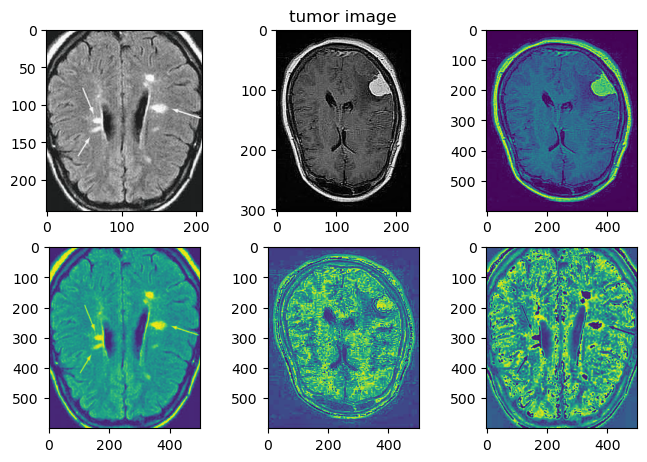

In [6]:
image_tumor = cv2.imread(os.path.join(tumor_images_ls[1]))
image_normal = cv2.imread(os.path.join(normal_images_ls[5]))
image1 = cv2.resize(image_tumor, (500, 600))
image2 = cv2.resize(image_normal, (500, 600))
# The initial processing of the image
# image = cv2.medianBlur(image, 3)
image_gr1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
image_gr2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit = 5)
final_img1 = clahe.apply(image_gr1) + 30
final_img2 = clahe.apply(image_gr2) + 30
# Ordinary thresholding the same image
_, ordinary_img1 = cv2.threshold(image_gr1, 155, 255, cv2.THRESH_BINARY)
_, ordinary_img2= cv2.threshold(image_gr2, 155, 255, cv2.THRESH_BINARY)
# Showing all the three images
f = plt.figure(figsize=(8, 8))
f.add_subplot(3, 3, 1)

plt.imshow(image_normal)
f.add_subplot(3, 3, 2)
plt.imshow(image_tumor)
plt.title("tumor image")
f.add_subplot(3, 3, 3)
plt.imshow(image_gr1)
f.add_subplot(3, 3, 4)
plt.imshow(image_gr2)
f.add_subplot(3, 3, 5)
plt.imshow(final_img1)
f.add_subplot(3, 3, 6)
plt.imshow(final_img2)

In [7]:
print("Image tumor Shape {}".format(image_tumor.shape))
print("Image normal Shape {}".format(image_normal.shape))

Image tumor Shape (303, 223, 3)
Image normal Shape (242, 208, 3)


In [8]:
# Create Train-Test Directory
subdirs  = ['train/', 'test/']
for subdir in subdirs:
    labeldirs = ['tumor', 'Normal']
    for labldir in labeldirs:
        newdir = subdir + labldir
        os.makedirs(newdir, exist_ok=True)
        print(newdir)

train/tumor
train/Normal
test/tumor
test/Normal


In [9]:
# Copy Images to test set

# seed random number generator
random.seed(237)
# define ratio of pictures used for testing
test_ratio = 0.2


for cases in [tumor, Normal]:
    total_cases = len(cases['images']) #number of total images
    num_to_select = int(test_ratio * total_cases) #number of images to copy to test set

    print(cases['class'], num_to_select)

    list_of_random_files = random.sample(cases['images'], num_to_select) #random files selected

    for files in list_of_random_files:
        shutil.copy2(files, 'test/' + cases['class'])

tumor 138
normal 309


In [10]:
# Copy Images to train set
for cases in [tumor,Normal]:
    image_test_files = os.listdir('test/' + cases['class']) # list test files
    for images in cases['images']:
        if images.split('/')[-1] not in (image_test_files): #exclude test files from shutil.copy
            shutil.copy2(images, 'train/' + cases['class'])

In [11]:
total_train_tumor = len(os.listdir('C:/Users/saipa/Music/BRAIN TUMOR/BRAIN TUMOR/train/tumor'))
total_train_normal = len(os.listdir('C:/Users/saipa/Music/BRAIN TUMOR/BRAIN TUMOR/train/normal'))
total_test_tumor = len(os.listdir('C:/Users/saipa/Music/BRAIN TUMOR/BRAIN TUMOR/test/tumor'))
total_test_normal = len(os.listdir('C:/Users/saipa/Music/BRAIN TUMOR/BRAIN TUMOR/test/normal'))

print("Train sets images tumor: {}".format(total_train_tumor))
print("Train sets images normal: {}".format(total_train_normal))
print("Test sets images tumor: {}".format(total_test_tumor))
print("Test sets images normal: {}".format(total_test_normal))

Train sets images tumor: 690
Train sets images normal: 773
Test sets images tumor: 690
Test sets images normal: 773


#CNN MODEL

In [12]:
batch_size =55
epochs = 5
IMG_HEIGHT = 150
IMG_WIDTH = 150

In [13]:
train_image_generator = ImageDataGenerator(rescale=1./255) # Generator for our training data
test_image_generator = ImageDataGenerator(rescale=1./255) # Generator for our validation data

In [14]:
train_dir = os.path.join('C:/Users/saipa/Music/BRAIN TUMOR/BRAIN TUMOR/datasets')
test_dir = os.path.join('C:/Users/saipa/Music/BRAIN TUMOR/BRAIN TUMOR/datasets')


total_train = total_train_tumor + total_train_normal
total_test = total_test_tumor + total_test_normal

In [15]:
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                           directory=train_dir,
                                                           shuffle=True,
                                                           target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                           class_mode='binary')

Found 1463 images belonging to 2 classes.


In [16]:
test_data_gen = test_image_generator.flow_from_directory(batch_size=batch_size,
                                                              directory=test_dir,
                                                              target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                              class_mode='binary')

Found 1463 images belonging to 2 classes.


In [17]:
model = Sequential([
    Conv2D(32, 3, padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH ,3)),
    MaxPooling2D(2, 2),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1)

])

In [18]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 32, 32, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 128)       0

In [20]:
history = model.fit_generator(
    train_data_gen,
    steps_per_epoch=total_train // batch_size,
    epochs=8,
    validation_data=test_data_gen,
    validation_steps=total_test // batch_size
)

C:\Users\saipa\AppData\Local\Temp\ipykernel_18720\122864321.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/8


26/26 [==============================] - 35s 1s/step - loss: 0.5876 - accuracy: 0.7024 - val_loss: 0.4560 - val_accuracy: 0.8056
Epoch 2/8
26/26 [==============================] - 31s 1s/step - loss: 0.4107 - accuracy: 0.8033 - val_loss: 0.3109 - val_accuracy: 0.8392
Epoch 3/8
26/26 [==============================] - 30s 1s/step - loss: 0.2852 - accuracy: 0.8743 - val_loss: 0.2011 - val_accuracy: 0.9196
Epoch 4/8
26/26 [==============================] - 30s 1s/step - loss: 0.2026 - accuracy: 0.9134 - val_loss: 0.1918 - val_accuracy: 0.8853
Epoch 5/8
26/26 [==============================] - 30s 1s/step - loss: 0.1307 - accuracy: 0.9595 - val_loss: 0.1757 - val_accuracy: 0.8797
Epoch 6/8
26/26 [==============================] - 31s 1s/step - loss: 0.0993 - accuracy: 0.9602 - val_loss: 0.0487 - val_accuracy: 0.9895
Epoch 7/8
26/26 [==============================] - 30s 1s/step - loss: 0.0323 - accuracy: 0.9915 - val_loss: 0.0192 - val_accuracy: 0.9951
Epoch 8/8
26/26 [========

In [21]:

##VGG model
#import split_folders
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D , Flatten
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import metrics

from sklearn.utils import class_weight
from collections import Counter

import matplotlib.pyplot as plt

import os
from os import listdir
from os.path import isfile, join


In [22]:
for layer in model.layers:
    layer.trainable = False

for layer in model.layers[-16:]:
    layer.trainable = True
    print("Layer '%s' is trainable" % layer.name)


Layer 'conv2d' is trainable
Layer 'max_pooling2d' is trainable
Layer 'conv2d_1' is trainable
Layer 'max_pooling2d_1' is trainable
Layer 'conv2d_2' is trainable
Layer 'max_pooling2d_2' is trainable
Layer 'flatten' is trainable
Layer 'dense' is trainable
Layer 'dense_1' is trainable


In [23]:
checkpoint = ModelCheckpoint("vgg16_disease.h5", monitor='val_accuracy', verbose=1,
                             saave_best_only=True, save_weights_only=False, mode='auto')
early = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=20, verbose=1, mode='auto')

In [24]:
opt = Adam(lr=0.000001)
model.compile(optimizer=opt, loss=categorical_crossentropy,
              metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 32, 32, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 128)       0

In [25]:
hist = model.fit(train_data_gen, steps_per_epoch=train_data_gen.samples//train_data_gen.batch_size, validation_data=test_data_gen,
                 validation_steps=test_data_gen.samples//test_data_gen.batch_size,
                 epochs=5,callbacks=[checkpoint,early])

Epoch 1/5


C:\Users\saipa\anaconda3\Lib\site-packages\tensorflow\python\util\dispatch.py:1260: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return dispatch_target(*args, **kwargs)


26/26 [==============================] - ETA: 0s - loss: 5.6218e-08 - accuracy: 0.9986
Epoch 1: saving model to vgg16_disease.h5


C:\Users\saipa\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


26/26 [==============================] - 34s 1s/step - loss: 5.6218e-08 - accuracy: 0.9986 - val_loss: 5.6020e-08 - val_accuracy: 0.9986
Epoch 2/5
26/26 [==============================] - ETA: 0s - loss: 5.5879e-08 - accuracy: 0.9986
Epoch 2: saving model to vgg16_disease.h5
26/26 [==============================] - 30s 1s/step - loss: 5.5879e-08 - accuracy: 0.9986 - val_loss: 5.6270e-08 - val_accuracy: 0.9986
Epoch 3/5
26/26 [==============================] - ETA: 0s - loss: 5.6641e-08 - accuracy: 0.9986
Epoch 3: saving model to vgg16_disease.h5
26/26 [==============================] - 31s 1s/step - loss: 5.6641e-08 - accuracy: 0.9986 - val_loss: 5.6770e-08 - val_accuracy: 0.9986
Epoch 4/5
26/26 [==============================] - ETA: 0s - loss: 5.6557e-08 - accuracy: 0.9986
Epoch 4: saving model to vgg16_disease.h5
26/26 [==============================] - 31s 1s/step - loss: 5.6557e-08 - accuracy: 0.9986 - val_loss: 5.6353e-08 - val_accuracy: 0.9986
Epoch 5/5
26/26 [==================

In [26]:
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np

# Predict classes for test images
predictions = model.predict(test_data_gen)
predicted_classes = np.where(predictions > 0, 1, 0)  # Assuming 0 is normal and 1 is tumor

# Get true classes for test images
true_classes = np.array([0] * total_test_normal + [1] * total_test_tumor)  # Assuming 0 is normal and 1 is tumor

# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)
'''report = classification_report(true_labels, predicted_classes, target_names=['Normal', 'Tumor'])

print("Classification Report:")
print(report)
'''

27/27 [==============================] - 9s 335ms/step
Confusion Matrix:
[[401 372]
 [371 319]]


'report = classification_report(true_labels, predicted_classes, target_names=[\'Normal\', \'Tumor\'])\n\nprint("Classification Report:")\nprint(report)\n'

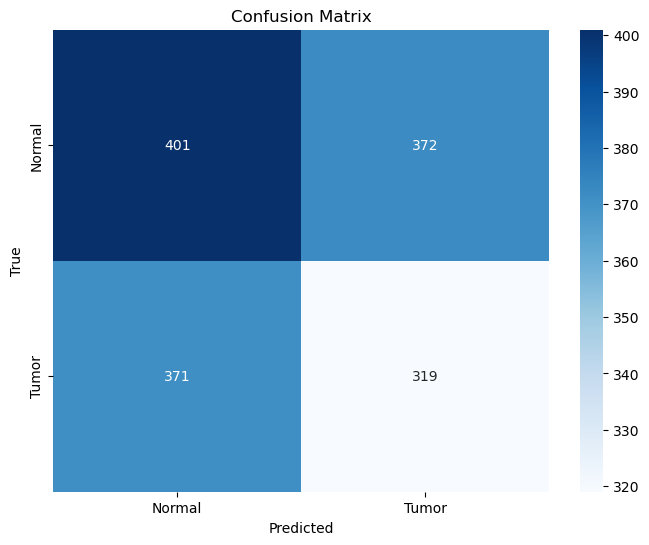

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels
class_labels = ['Normal', 'Tumor']

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [31]:
def preprocess_image(img_path):
    # Load image using your preferred method (e.g., cv2.imread, PIL.Image.open)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))  # Reshape to VGG16 input size
    img = img.astype('float32')  # Convert to float
    img /= 255.0  # Normalize to range [0, 1]
    return img


In [32]:
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


In [35]:
# Replace with your testing data and predicted labels
# Included in your code:
# ... (data preparation and model training)

true_labels = np.array([0] * total_test_normal + [1] * total_test_tumor)  # Assuming 0 is normal and 1 is tumor
# List of actual labels for testing data
predicted_labels = model.predict(test_data_gen)  # Predict labels for testing images


27/27 [==============================] - 9s 325ms/step


In [38]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_data_gen)
print('Test accuracy:', test_acc)

# Get predictions and ground truth labels
predictions = np.argmax(model.predict(test_data_gen), axis=-1)
true_labels = test_data_gen.classes

# Generate confusion matrix
cm = confusion_matrix(true_labels, predictions)
print('Confusion Matrix:\n', cm)

# Generate classification report
print('Classification Report:\n', classification_report(true_labels, predictions))


27/27 [==============================] - 9s 336ms/step - loss: 5.6223e-08 - accuracy: 0.9986
Test accuracy: 0.9986329674720764
27/27 [==============================] - 9s 334ms/step
Confusion Matrix:
 [[773   0]
 [690   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.53      1.00      0.69       773
           1       0.00      0.00      0.00       690

    accuracy                           0.53      1463
   macro avg       0.26      0.50      0.35      1463
weighted avg       0.28      0.53      0.37      1463



C:\Users\saipa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\saipa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\saipa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


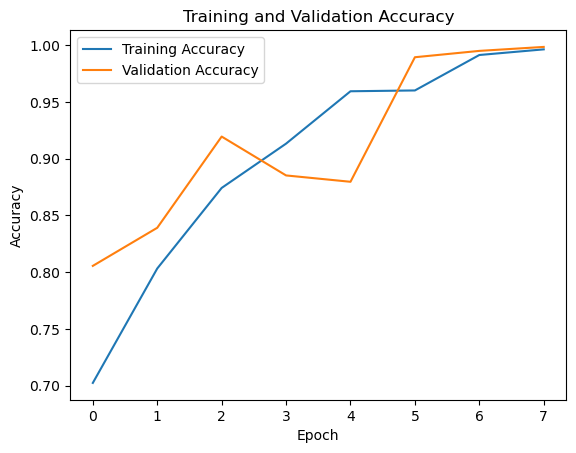

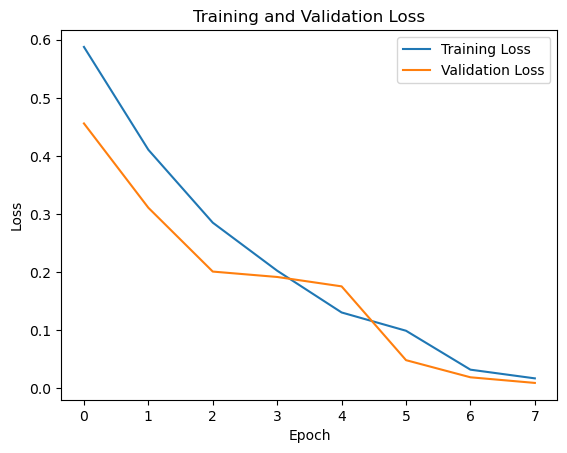

In [39]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


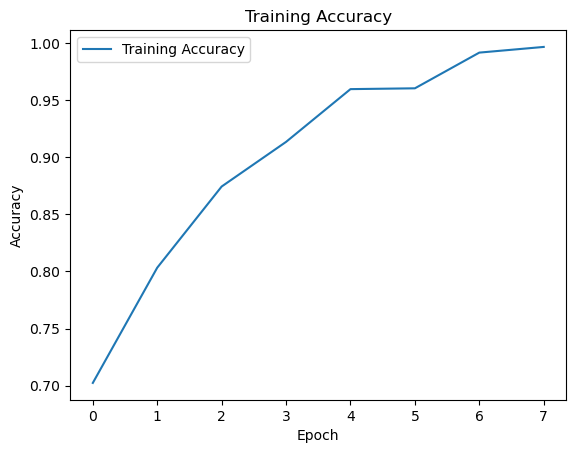

Final Training Accuracy: 99.64%


In [44]:
import matplotlib.pyplot as plt

# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Print training accuracy values
final_training_accuracy = history.history['accuracy'][-1] * 100
print("Final Training Accuracy: %.2f%%" % final_training_accuracy)


In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import numpy as np
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Dense
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import numpy as np
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Dense
from keras.models import model_from_json
import tensorflow as tf
from flask import Flask, render_template, request, send_from_directory

app = Flask(__name__)


UPLOAD_FOLDER = "uploads"
STATIC_FOLDER = "static"
json_file = open('model_vgg.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
cnn_model = model_from_json(loaded_model_json)
# load weights into new model
cnn_model.load_weights("model_vgg.h5")
# Load model

IMAGE_SIZE = 150

# Preprocess an image
def preprocess_image(image):
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image /= 255.0  # normalize to [0,1] range

    return image


# Read the image from path and preprocess
def load_and_preprocess_image(path):
    image = tf.io.read_file(path)

    return preprocess_image(image)


# Predict & classify image
def classify(model, image_path):

    preprocessed_imgage = load_and_preprocess_image(image_path)
    preprocessed_imgage = tf.reshape(
        preprocessed_imgage, (1, IMAGE_SIZE, IMAGE_SIZE, 3)
    )

    prob = cnn_model.predict(preprocessed_imgage)
    label = "Brain tumor" if prob[0][0] >= 0.5 else "Normal"
    classified_prob = prob[0][0] if prob[0][0] >= 0.5 else 1 - prob[0][0]

    return label, classified_prob


# home page
@app.route("/")
def home():
    return render_template("home.html")


@app.route("/classify", methods=["POST", "GET"])
def upload_file():

    if request.method == "GET":
        return render_template("home.html")

    else:
        file = request.files["image"]
        upload_image_path = os.path.join(UPLOAD_FOLDER, file.filename)
        print(upload_image_path)
        file.save(upload_image_path)

        label, prob = classify(cnn_model, upload_image_path)

        prob = round((prob * 100), 2)

    return render_template(
        "classify.html", image_file_name=file.filename, label=label, prob=prob
    )


@app.route("/classify/<filename>")
def send_file(filename):
    return send_from_directory(UPLOAD_FOLDER, filename)


if __name__ == "__main__":
    
    app.run()
   


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
